In [1]:
import os 
from typing import Literal, TypedDict

from langchain.chat_models import init_chat_model
from langchain_core.prompts import SystemMessagePromptTemplate, MessagesPlaceholder, ChatPromptTemplate
from langchain.schema import HumanMessage, AIMessage
from langchain_core.output_parsers import JsonOutputParser

from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode
from pydantic.v1 import BaseModel, Field
from plantweb.render import render
from IPython.display import SVG

In [2]:
# 1. 先设置提示词

system_prompt = """You are a patent assistant, and the user will provide a technical title. You need to generate the following four parts based on the title:
1. * * Technical Background * *: Briefly describe the background information of the technology, with a word count controlled between 20-100 words.
2. * * Technical problem * *: Briefly describe the technical problem that the technology aims to solve, with a word count controlled between 50-500 words.
3. * * Technical Solution * *: Briefly describe the main technical means and solutions used in the technology, with a word count controlled between 50-500 words.
4. PlantUML flowchart: Use PlantUML syntax to draw the implementation flowchart of this technology.
**Example input:**
Title: Improving the Corrosion Resistance of Neodymium Iron Boron
**Example output:**
1. * * Technical Background * *: Neodymium iron boron magnets are widely used due to their high magnetic energy product, but their poor corrosion resistance limits their use in harsh environments.
2. * * Technical issue * *: Traditional neodymium iron boron magnets are prone to oxidation and corrosion in humid or corrosive environments, leading to a decrease in magnetic properties and a shortened service life.
3. * * Technical solution * *: Adopting anti-corrosion coating technology, a layer of anti-corrosion coating (such as fluorocarbon paint) is applied on the surface of neodymium iron boron magnets to enhance their corrosion resistance through physical isolation and chemical stability.
4. PlantUML flowchart:
```plantuml
@startuml
start
Prepare neodymium iron boron magnets;
Surface cleaning treatment;
Coating with anti-corrosion coating (such as fluorocarbon paint);
Curing treatment;
Testing the quality of coatings;
end
@enduml
```
---
**Instructions for use:**
After the user provides the technical title, the model will automatically generate four parts of content.
2. The technical background, technical issues, and technical solutions should be concise and clear, highlighting key points.
3. The PlantUML flowchart should clearly demonstrate the key steps of technical implementation.
**Attention:**
-If the title provided by the user involves complex technology, the details of the technical solution and flowchart can be appropriately added.
-Ensure logical consistency between technical issues and solutions.
Answer all questions to the best of your ability in {language}.
"""

In [3]:
system_msg_prompt = SystemMessagePromptTemplate.from_template(
    system_prompt,
    input_variables=["title", "language"],
    partial_variables={"language": "Chinese"}
)

prompt_template = ChatPromptTemplate.from_messages([
    system_msg_prompt,
    MessagesPlaceholder(variable_name="messages")
])

In [4]:
prompt_template.invoke({
    "messages": [HumanMessage("写一篇关于langchain的技术专利")],
    "language": "Chinese",
    "title": "用户输入的专利标题"
})

ChatPromptValue(messages=[SystemMessage(content='You are a patent assistant, and the user will provide a technical title. You need to generate the following four parts based on the title:\n1. * * Technical Background * *: Briefly describe the background information of the technology, with a word count controlled between 20-100 words.\n2. * * Technical problem * *: Briefly describe the technical problem that the technology aims to solve, with a word count controlled between 50-500 words.\n3. * * Technical Solution * *: Briefly describe the main technical means and solutions used in the technology, with a word count controlled between 50-500 words.\n4. PlantUML flowchart: Use PlantUML syntax to draw the implementation flowchart of this technology.\n**Example input:**\nTitle: Improving the Corrosion Resistance of Neodymium Iron Boron\n**Example output:**\n1. * * Technical Background * *: Neodymium iron boron magnets are widely used due to their high magnetic energy product, but their poor

In [5]:
class ZhuanLiItem(BaseModel):
    title: str = Field(description="User Provided Patent Title")
    background: str = Field(description="Technical Background Description of Model Generation")
    issues: str = Field(description="Description of Technical Issues in Model Generation")
    solution: str = Field(description="Description of Technical Scheme for Model Generation")
    plantuml: str = Field(description="PlantUML code generated by model")

In [6]:
# 实例化模型
model_name = "qwen2.5:7b"
# model_name = "qwq:32b"
ollama_api_base = os.environ["OLLAMA_API_BASE"]
model = init_chat_model(model=model_name, model_provider="ollama", base_url=ollama_api_base)

zhuanli_gen_chain = prompt_template | model.with_structured_output(ZhuanLiItem)

model_ds = init_chat_model(model="deepseek-chat", model_provider="deepseek")
zhuanli_gen_chain_ds = prompt_template | model_ds.with_structured_output(ZhuanLiItem)

In [7]:
question = "用户登录注册叠加图形验证码"
result = zhuanli_gen_chain.invoke({
    "messages": [HumanMessage(content=question)],
})
result

ZhuanLiItem(title='用户登录注册叠加图形验证码', background='随着互联网应用的广泛普及，传统的用户名和密码验证方式已经难以满足日益增长的安全需求。为了提升账户安全性，在登录或注册过程中加入图形验证码是一个有效的解决方案。', issues='传统验证方式容易受到自动化脚本攻击，导致大量垃圾账号注册、暴力破解等问题。如何在保持良好用户体验的同时提高安全性和便捷性成为一大挑战。', solution='通过叠加图形验证码的方式增加账户安全性，在不显著提升用户操作复杂度的前提下有效应对各种恶意行为。', plantuml='@startuml\nstart\n显示登录/注册页面;\n生成并显示图形验证码;\n用户输入图形验证码;\n验证用户输入的图形验证码是否正确;\n如果(验证码验证通过) then (true branch)\n继续执行下一步操作，如账户创建或登录等;\n否则(false branch)\n提示错误信息：请重新输入正确的图形验证码;\nend\n@enduml')

In [8]:
try:
    # 把plantuml转化为svg图片
    svg_output = render(result.plantuml, engine='plantuml', format='svg', cacheopts={'use_cache': False})
    
    # 显示svg图片
    SVG(svg_output[0])
except Exception as e:
    svg_output = None
    print("显示流程图出错：{}\n\n".format(str(e)))
    print(result.plantuml)

SVG(svg_output[0]) if svg_output else ""

显示流程图出错：400 Client Error: Bad Request for url: http://www.plantuml.com/plantuml/svg/PP3DJi9G48NtzocwX9KFq0slKhM61NPHofuQbH9BR08IMl2dA8MOr6kY259QNgOpzzuLh-3L6ZMocPpad9oPRofrIpEjnd6DV0c2Wumzh9YVG7grXoypE7T5E1VNOvMmtYqw7ho_5HaOPf2EnQFBgStkx4z_Xiw2Prquc-oOt_9FX0Md_r8ueE156D-py4ab49tWpQZqunP2D0E-QPKLgweRIiao6xgoRsh6GRLCM39bIOpjAG_TV7cHBviOJx3RoTFHTktAEluQoUtW325PeTCl85dSbhky21o_TAJLwhzzUEb9JD7pEQNv9aIRRjS1fmlHwc3_kO0eZjr5KObk79AA7FAr7m00


@startuml
start
显示登录/注册页面;
生成并显示图形验证码;
用户输入图形验证码;
验证用户输入的图形验证码是否正确;
如果(验证码验证通过) then (true branch)
继续执行下一步操作，如账户创建或登录等;
否则(false branch)
提示错误信息：请重新输入正确的图形验证码;
end
@enduml


''

In [10]:
question = "用户登录注册叠加图形验证码"
result_ds = zhuanli_gen_chain_ds.invoke({
    "messages": [HumanMessage(content=question)],
})
result_ds

ZhuanLiItem(title='用户登录注册叠加图形验证码', background='随着互联网的发展，用户登录和注册系统已成为各类网站和应用的基础功能。然而，传统的用户名和密码验证方式存在安全隐患，容易受到暴力破解和自动化攻击。', issues='传统的用户登录和注册系统主要依赖于用户名和密码的验证方式，这种方式存在以下问题：1. 用户名和密码容易被暴力破解或猜测；2. 自动化脚本可以快速尝试大量组合，导致账户被盗；3. 用户密码设置过于简单，容易被破解。为了提高安全性，需要一种更可靠的验证方式。', solution='为了解决上述问题，采用图形验证码技术来增强用户登录和注册的安全性。具体步骤如下：1. 在用户登录或注册页面，生成并显示一个图形验证码；2. 用户需要正确输入图形验证码中的字符或完成指定的图形操作；3. 系统验证用户输入的验证码是否正确，只有验证通过后才能继续登录或注册流程。这种方法可以有效防止自动化脚本的攻击，提高系统的安全性。', plantuml='@startuml\nstart\n:显示登录/注册页面;\n:生成图形验证码;\n:显示图形验证码;\n:用户输入验证码;\nif (验证码正确?) then (是)\n  :继续登录/注册流程;\nelse (否)\n  :提示验证码错误;\n  :重新生成验证码;\nendif\nend\n@enduml')

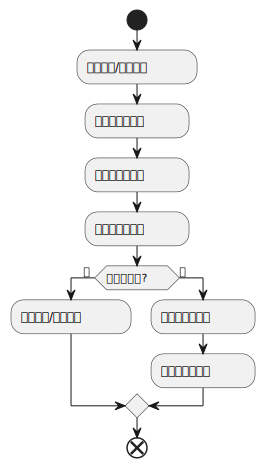

In [11]:
try:
    # 把plantuml转化为svg图片
    svg_output = render(result_ds.plantuml, engine='plantuml', format='svg', cacheopts={'use_cache': False})

except Exception as e:
    svg_output = None
    print("显示流程图出错：{}\n\n".format(str(e)))
    print(result_ds.plantuml)

# 显示svg图片
SVG(svg_output[0]) if svg_output else ""

In [12]:
question = "智能体中人工审批调用tools"
result_ds = zhuanli_gen_chain_ds.invoke({
    "messages": [HumanMessage(content=question)],
    "language": "English"
})
result_ds

ZhuanLiItem(title='智能体中人工审批调用', background='智能体（Agent）技术在自动化流程中广泛应用，但在某些复杂场景下仍需要人工审批以确保决策的准确性和合规性。', issues='在智能体自动化流程中，某些决策需要人工审批以确保其准确性和合规性。然而，现有的智能体系统在调用人工审批时存在效率低下、流程不透明、审批结果反馈不及时等问题，影响了整体流程的效率和用户体验。', solution='通过在智能体中集成人工审批调用模块，实现自动化流程与人工审批的无缝衔接。具体方案包括：1. 设计智能审批触发机制，当系统检测到需要人工审批的决策时，自动触发审批流程；2. 提供审批任务分配功能，根据审批人员的职责和权限自动分配任务；3. 实现审批结果实时反馈，确保审批结果能够及时返回智能体系统，继续后续流程。', plantuml='@startuml\nstart\n:智能体自动化流程;\nif (需要人工审批?) then (yes)\n  :触发人工审批流程;\n  :审批任务分配;\n  :人工审批;\n  :审批结果反馈;\nelse (no)\n  :继续自动化流程;\nendif\nend\n@enduml')

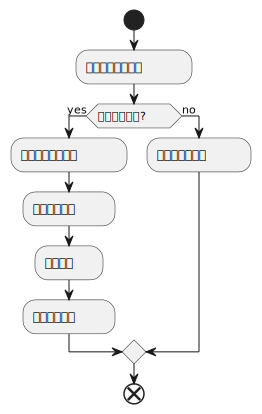

In [13]:
try:
    # 把plantuml转化为svg图片
    svg_output = render(result_ds.plantuml, engine='plantuml', format='svg', cacheopts={'use_cache': False})
    
    # 显示svg图片
    # SVG(svg_output[0])
except Exception as e:
    svg_output = None
    print("显示流程图出错：{}\n\n".format(str(e)))
    print(result_ds.plantuml)

# 显示svg图片
SVG(svg_output[0]) if svg_output else ""